<a href="https://www.kaggle.com/code/awsaf49/detect-fake-text-kerasnlp-tf-torch-jax-train?scriptVersionId=159282003" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# LLM - Detect AI Generated Text
> Identify which essay was written by a large language model

<img src="https://user-images.githubusercontent.com/36858976/279902422-b365f6ef-ef01-49ac-af7f-0bc2ca3ba835.png">

# 🎯 | Motivation

* In this notebook, we will demonstrate the usage of the multi-backend capabilities of `KerasCore` and `KerasNLP` for the **Detecting Fake Text** task.
* Thanks to `KerasCore`, soon to become `Keras 3.0`, which enables seamless execution of this notebook on `TensorFlow`, `Jax`, and `PyTorch` platforms with minimal adjustments required.
* Moreover, this notebook supports both single/multi GPU and TPU training. As time progresses, larger datasets may become available, making TPUs invaluable for training substantial models on these extensive datasets.
* Finally, I am very curious about the effectiveness of this competition, as a few months ago, `OpenAI` shut down their AI Text-Detection Tool due to inaccuracies ([ref](https://www.pcmag.com/news/openai-quietly-shuts-down-ai-text-detection-tool-over-inaccuracies)). So, I'm eager to see how well this competition will address the problem.
<img src="https://i.ibb.co/6Y2Vtgr/openAI.jpg" alt="openAI" border="0">

# 📓 | Notebooks

* Train: [Detect Fake Text: KerasNLP [TF/Torch/JAX][Train]](https://www.kaggle.com/code/awsaf49/detect-fake-text-kerasnlp-tf-torch-jax-train)
* Infer: [Detect Fake Text: KerasNLP [TF/Torch/JAX][Infer]](https://www.kaggle.com/code/awsaf49/detect-fake-text-kerasnlp-tf-torch-jax-infer)

# 🛠 | Install Libraries 

In [2]:
!pip install keras==2.15.0 keras-core==0.1.7 keras-nlp==0.6.3

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


# 📚 | Import Libraries 

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
# os.environ["KERAS_BACKEND"] = "jax"  # "jax" or "tensorflow" or "torch" 
# os.environ["WANDB_SILENT"] = "false" # for wandb

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import keras_nlp
import keras_core as keras
import keras_core.backend as K

# import torch
# import jax
import tensorflow as tf

import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = mpl.cm.get_cmap('coolwarm')

2026-05-26 09:34:07.557841: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-26 09:34:06.369068: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-26 09:34:06.369170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-26 09:34:06.431627: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-26 09:34:06.555486: I tensorflow/core/platform/cpu_feature_guar

Using TensorFlow backend


/tmp/ipykernel_417/1444212643.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('coolwarm')


## Library Version

In [2]:
print("TensorFlow:", tf.__version__)
# print("JAX:", jax.__version__)
print("Keras:", keras.__version__)
print("KerasNLP:", keras_nlp.__version__)

TensorFlow: 2.15.0
Keras: 0.1.7
KerasNLP: 0.6.3


# ⚙️ | Configuration

In [3]:
class CFG:
    verbose = 0  # Verbosity
    
    wandb = True  # Weights & Biases logging
    competition = 'llm-detect-ai-generated-text'  # Competition name
    _wandb_kernel = 'awsaf49'  # WandB kernel
    comment = 'DebertaV3-MaxSeq_200-ext_s-torch'  # Comment description
    
    preset = "deberta_v3_base_en"  # Name of pretrained models
    sequence_length = 200  # Input sequence length
    
    device = 'TPU'  # Device
    
    seed = 42  # Random seed
    
    num_folds = 5  # Total folds
    selected_folds = [0, 1]  # Folds to train on
    
    epochs = 3 # Training epochs
    batch_size = 3  # Batch size
    drop_remainder = True  # Drop incomplete batches
    cache = True # Caches data after one iteration, use only with `TPU` to avoid OOM
    
    scheduler = 'cosine'  # Learning rate scheduler
    
    # class_names = ["real", "half-truth", "fake"]  # Class names [A, B, C, D, E]
    class_names = ["HWT", "HLT", "LGT"]  # Class names [A, B, C, D, E]
    num_classes = len(class_names)  # Number of classes
    class_labels = list(range(num_classes))  # Class labels [0, 1, 2, 3, 4]
    label2name = dict(zip(class_labels, class_names))  # Label to class name mapping
    name2label = {v: k for k, v in label2name.items()}  # Class name to label mapping

# ♻️ | Reproducibility 
Sets value for random seed to produce similar result in each run.

In [4]:
keras.utils.set_random_seed(CFG.seed)

# 💾 | Hardware
Following codes automatically detects hardware (TPU or GPU). 

In [5]:
def get_device():
    "Detect and intializes GPU/TPU automatically"
    try:
        # detect and init the TPU
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()

        # instantiate a distribution strategy
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f'> Running on TPU', tpu.master(), end=' | ')
        print('Num of TPUs: ', strategy.num_replicas_in_sync)
        device=CFG.device
    except:
        # If TPU is not available, detect GPUs
        gpus = tf.config.list_logical_devices('GPU')
        ngpu = len(gpus)
         # Check number of GPUs
        if ngpu:
            # Set GPU strategy
            # strategy = tf.distribute.MirroredStrategy(gpus) # single-GPU or multi-GPU
            strategy = tf.distribute.get_strategy()
            # Print GPU details
            print("> Running on GPU", end=' | ')
            print("Num of GPUs: ", ngpu)
            device='GPU'
        else:
            # If no GPUs are available, use CPU
            print("> Running on CPU")
            strategy = tf.distribute.get_strategy()
            device='CPU'
    return strategy, device

In [6]:
# Initialize GPU/TPU/TPU-VM
strategy, CFG.device = get_device()
CFG.replicas = strategy.num_replicas_in_sync

> Running on CPU


2026-05-26 09:34:38.877147: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


先确认 TensorFlow 是 GPU 版本

运行：

In [7]:
import tensorflow as tf
print(tf.__version__)
print(tf.test.is_built_with_cuda())
print(tf.config.list_physical_devices('GPU'))

2.15.0
True
[]


请在你的 WSL Ubuntu 里执行：

In [8]:
!nvidia-smi

Tue May 26 09:10:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0  On |                  N/A |
|  0%   42C    P8             30W /  390W |    3854MiB /  24576MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

如果正常，你会看到显卡信息。

然后执行：

In [9]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Jan__6_16:45:21_PST_2023
Cuda compilation tools, release 12.0, V12.0.140
Build cuda_12.0.r12.0/compiler.32267302_0


测试 GPU

执行：

In [10]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.15.0
[]


# 📁 | Dataset Path 

In [2]:
# !pip install kagglehub

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/70/14/7b1f40778a4c8930f46b5841902647396069ccaa21cb8e0779ee822ffa77/kagglehub-1.0.1-py3-none-any.whl (70 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/8f/4e/fead499e4e76f66203611ecee1032fc8da87f2ab59c3921c76b06334cbbf/kagglesdk-0.1.23-py3-none-any.whl (217 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]/2 [kagglehub]


In [8]:
# !pip install kaggle

In [7]:
# ls

detect-fake-text-kerasnlp-tf-torch-jax-infer.ipynb*  kaggle/
detect-fake-text-kerasnlp-tf-torch-jax-train.ipynb*  kaggle.json*


In [3]:
# mv ./kaggle.json ~/.kaggle/

In [6]:
# cp ~/.kaggle/kaggle.json ./kaggle.json

In [9]:
# !kaggle competitions list

ref                                                                                          deadline             category              reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------------------  -------------------  ---------------  -----------  ---------  --------------  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                                 2026-11-02 23:59:00  Featured         850,000 Usd        794           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-2                                 2026-11-02 23:59:00  Featured         700,000 Usd        583           False  
https://www.kaggle.com/competitions/arc-prize-2026-paper-track                               2026-11-09 23:59:00  Featured         450,000 Usd         45           False  
https://www.kaggle.com/competitions/gemma-4-good-hackathon                                   2026-05-18 23:59:00  Featured         200,000 U

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.competition_download('llm-detect-ai-generated-text')

# print("Path to competition files:", path)

In [6]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("thedrcat/daigt-v2-train-dataset")

# print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 28.5M/28.5M [00:07<00:00, 4.14MB/s]

Extracting model files...


Path to dataset files: /home/wangkongqiang/.cache/kagglehub/datasets/thedrcat/daigt-v2-train-dataset/versions/2


In [3]:
# ls /home/wangkongqiang/.cache/kagglehub/datasets/thedrcat/daigt-v2-train-dataset/versions/2

train_v2_drcat_02.csv


In [5]:
# cp /home/wangkongqiang/.cache/kagglehub/datasets/thedrcat/daigt-v2-train-dataset/versions/2/train_v2_drcat_02.csv ./kaggle/input/llm-detect-ai-generated-text/train_v2_drcat_02.csv

data/train_data.json 转换后得到的 data/train_data.csv 格式如下：

In [11]:
import json
import pandas as pd

# 输入输出文件
json_file = "data/train_data.json"
csv_file = "data/train_data.csv"

# 读取 JSON 文件
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# 标签映射
label_map = {
    "HWT": 0,
    "HLT": 1,
    "LGT": 2
}

# 保存转换后的数据
rows = []

for item in data:
    base_id = item["ID"]

    for key in ["HWT", "HLT", "LGT"]:
        text = item.get(key, "").strip()

        # 构造唯一ID
        new_id = f"{base_id}_{key}"

        rows.append({
            "ID": new_id,
            "Text": text,
            "Label": label_map[key]
        })

# 转换为 DataFrame
df = pd.DataFrame(rows)

# 保存 CSV
df.to_csv(csv_file, index=False, encoding="utf-8-sig")

print(f"转换完成，共 {len(df)} 条数据")
print(df.head())

转换完成，共 58902 条数据
                              ID  \
0  GPT4-News-Rewrite-ID-2003_HWT   
1  GPT4-News-Rewrite-ID-2003_HLT   
2  GPT4-News-Rewrite-ID-2003_LGT   
3  GPT4-News-Rewrite-ID-2001_HWT   
4  GPT4-News-Rewrite-ID-2001_HLT   

                                                Text  Label  
0  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...      0  
1  广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...      1  
2  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...      2  
3  编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...      0  
4  在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...      1  


In [7]:
# BASE_PATH = './kaggle/input/llm-detect-ai-generated-text'
BASE_PATH = './data'

# 📖 | Meta Data 
* `{test|train}_essays.csv`
    * `id` - A unique identifier for each essay.
    * `prompt_id` - Identifies the prompt the essay was written in response to.
    * `text` - The essay text itself.
    * `generated` - Whether the essay was written by a student (0) or generated by an LLM (1). This field is the target and is not present in test_essays.csv.
* **sample_submission.csv** - is the valid sample submission.

## Train Data

# Train Data: 58,902
# Sample:


,ID,Text,Label,label,name
0,GPT4-News-Rewrite-ID-2003_HWT,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,0,HWT
1,GPT4-News-Rewrite-ID-2003_HLT,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,1,HLT


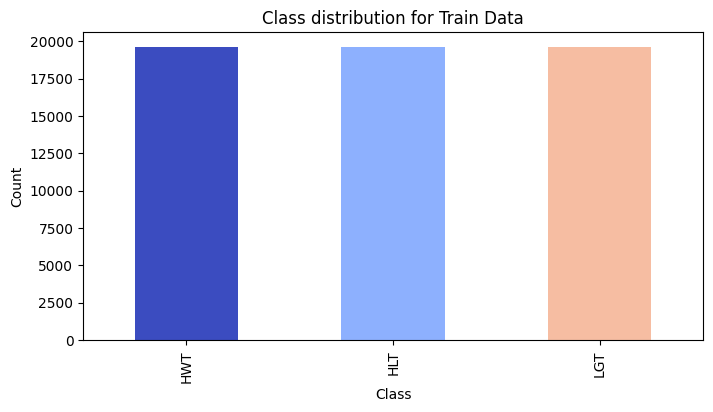

In [8]:
# df = pd.read_csv(f'{BASE_PATH}/train_essays.csv')  # Read CSV file into a DataFrame
df = pd.read_csv(f'{BASE_PATH}/train_data.csv')  # Read CSV file into a DataFrame
# df['label'] = df.generated.copy()
df['label'] = df.Label.copy()
# df['name'] = df.generated.map(CFG.label2name)  # Map answer labels using name-to-label mapping
df['name'] = df.Label.map(CFG.label2name)  # Map answer labels using name-to-label mapping

# Display information about the train data
print("# Train Data: {:,}".format(len(df)))
print("# Sample:")
display(df.head(2))

# Show distribution of answers using a bar plot
plt.figure(figsize=(8, 4))
df.name.value_counts().plot.bar(color=[cmap(0.0), cmap(0.25), cmap(0.65), cmap(0.9), cmap(1.0)])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution for Train Data")
plt.show()

## External Datasets

We'll be utilizing the following external datasets:

* [Proper Train Dataset](https://www.kaggle.com/datasets/thedrcat/daigt-proper-train-dataset/) @thedrcat
* [ArguGPT](https://www.kaggle.com/datasets/alejopaullier/argugpt) @alejopaullier


In [13]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("thedrcat/daigt-proper-train-dataset")

# print("Path to dataset files:", path)

Path to dataset files: /home/wangkongqiang/.cache/kagglehub/datasets/thedrcat/daigt-proper-train-dataset/versions/4


In [4]:
# ls /home/wangkongqiang/.cache/kagglehub/datasets/thedrcat/daigt-proper-train-dataset/versions/4

train_drcat_01.csv  train_drcat_02.csv  train_drcat_03.csv  train_drcat_04.csv


In [5]:
# cp /home/wangkongqiang/.cache/kagglehub/datasets/thedrcat/daigt-proper-train-dataset/versions/4/train_drcat_04.csv ./kaggle/input/daigt-proper-train-dataset/train_drcat_04.csv

In [6]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("alejopaullier/argugpt")

# print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 3.26M/3.26M [00:02<00:00, 1.29MB/s]

Extracting files...
Path to dataset files: /home/wangkongqiang/.cache/kagglehub/datasets/alejopaullier/argugpt/versions/1


In [7]:
# ls /home/wangkongqiang/.cache/kagglehub/datasets/alejopaullier/argugpt/versions/1

argugpt.csv  machine-dev.csv  machine-test.csv  machine-train.csv


In [8]:
# cp /home/wangkongqiang/.cache/kagglehub/datasets/alejopaullier/argugpt/versions/1/argugpt.csv ./kaggle/input/argugpt/argugpt.csv

# External Data: 58,902
# Sample:


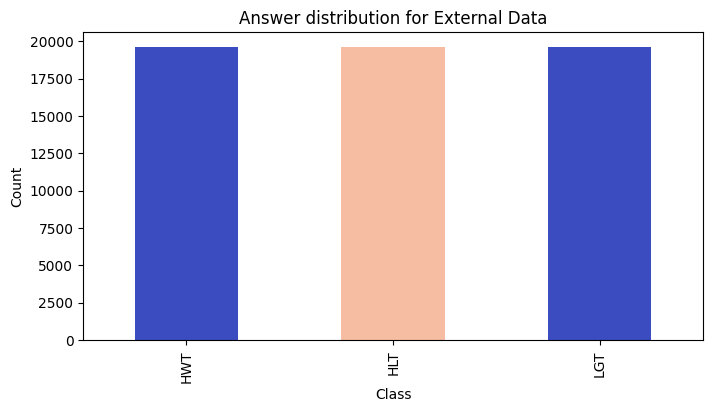

In [9]:
# Load external data
# ext_df1 = pd.read_csv('./kaggle/input/daigt-proper-train-dataset/train_drcat_04.csv')
# ext_df2 = pd.read_csv('./kaggle/input/argugpt/argugpt.csv')[['id','text','model']]

# ext_df2.rename(columns={'model':'source'}, inplace=True)
# ext_df2['label'] = 1

# ext_df = pd.concat([
#     ext_df1[ext_df1.source=='persuade_corpus'].sample(10000),
#     ext_df1[ext_df1.source!='persuade_corpus'],
# #     ext_df2,
# ])

ext_df = pd.read_csv('./data/train_data.csv')
ext_df["label"]=ext_df["Label"]
ext_df["text"]=ext_df["Text"]

# ext_real_df = ext_df[['id', 'text']].copy()
# ext_real_df['label']  = 0

# ext_fake_df = ext_df[['id', 'source_text']].copy()
# ext_fake_df.rename(columns={"source_text":"text"}, inplace=True)
# ext_fake_df['label']  = 1

# ext_df = pd.concat([ext_real_df, ext_fake_df], axis=0)
ext_df['name'] = ext_df.label.map(CFG.label2name)

# Display information about the external data
print("# External Data: {:,}".format(len(ext_df)))
print("# Sample:")
ext_df.head(2)

# Show distribution of answers using a bar plot
plt.figure(figsize=(8, 4))
ext_df.name.value_counts().plot.bar(color=[cmap(0.0), cmap(0.65)])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Answer distribution for External Data")
plt.show()

## Combine External and Train Data

In [10]:
df = ext_df.copy().reset_index(drop=True) # pd.concat([ext_df, df], axis=0)
df.head()

,ID,Text,Label,label,text,name
0,GPT4-News-Rewrite-ID-2003_HWT,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,HWT
1,GPT4-News-Rewrite-ID-2003_HLT,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,HLT
2,GPT4-News-Rewrite-ID-2003_LGT,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,LGT
3,GPT4-News-Rewrite-ID-2001_HWT,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,HWT
4,GPT4-News-Rewrite-ID-2001_HLT,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,HLT


# 🔪 | Data Split

In the code snippet provided below, we will divide the existing **train** data into folds using a stratification of `label` column.

In [11]:
import sklearn
print(sklearn.__version__)

1.7.2


In [12]:
from sklearn.model_selection import StratifiedKFold  # Import package

skf = StratifiedKFold(n_splits=CFG.num_folds, shuffle=True, random_state=CFG.seed)  # Initialize K-Fold

df = df.reset_index(drop=True)  # Reset dataframe index

# df['stratify'] = df.label.astype(str)+df.source.astype(str)
df['stratify'] = df.label.astype(str)+df.name.astype(str)

df["fold"] = -1  # New 'fold' column

# Assign folds using StratifiedKFold
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['stratify'])):
    df.loc[val_idx, 'fold'] = fold

# Display label distribution for each fold
# df.groupby(["fold", "name", "source"]).size()
df.groupby(["fold", "name", "stratify"]).size()

fold  name  stratify
0     HLT   1HLT        3927
      HWT   0HWT        3927
      LGT   2LGT        3927
1     HLT   1HLT        3927
      HWT   0HWT        3927
      LGT   2LGT        3927
2     HLT   1HLT        3927
      HWT   0HWT        3927
      LGT   2LGT        3926
3     HLT   1HLT        3926
      HWT   0HWT        3927
      LGT   2LGT        3927
4     HLT   1HLT        3927
      HWT   0HWT        3926
      LGT   2LGT        3927
dtype: int64

读取 csv 后立刻检查：

In [30]:
print(df.columns)
print(df.head())
print(df.isnull().sum())

Index(['ID', 'Text', 'Label', 'label', 'text', 'name', 'stratify', 'fold'], dtype='object')
                              ID  \
0  GPT4-News-Rewrite-ID-2003_HWT   
1  GPT4-News-Rewrite-ID-2003_HLT   
2  GPT4-News-Rewrite-ID-2003_LGT   
3  GPT4-News-Rewrite-ID-2001_HWT   
4  GPT4-News-Rewrite-ID-2001_HLT   

                                                Text  Label  label  \
0  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...      0      0   
1  广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...      1      1   
2  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...      2      2   
3  编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...      0      0   
4  在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...      1      1   

                                                text name stratify  fold  
0  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...  HWT     0HWT     1  
1  广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...  HLT     1HLT     3  
2  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动

In [31]:
df["text"] = df["text"].fillna("").astype(str)

# 🍽️ | Preprocessing

**What it does:** The preprocessor takes input strings and transforms them into a dictionary (`token_ids`, `padding_mask`) containing preprocessed tensors. This process starts with tokenization, where input strings are converted into sequences of token IDs.

**Why it's important:** Initially, raw text data is complex and challenging for modeling due to its high dimensionality. By converting text into a compact set of tokens, such as transforming `"The quick brown fox"` into `["the", "qu", "##ick", "br", "##own", "fox"]`, we simplify the data. Many models rely on special tokens and additional tensors to understand input. These tokens help divide input and identify padding, among other tasks. Making all sequences the same length through padding boosts computational efficiency, making subsequent steps smoother.

Explore the following pages to access the available preprocessing and tokenizer layers in **KerasNLP**:
- [Preprocessing](https://keras.io/api/keras_nlp/preprocessing_layers/)
- [Tokenizers](https://keras.io/api/keras_nlp/tokenizers/)

先查看 TensorFlow 版本：

In [18]:
!pip install tensorflow==2.15.0

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [21]:
import tensorflow as tf
print(tf.__version__)

2.15.0


那么你必须安装：

In [22]:
!pip install tensorflow-text==2.15.0

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [23]:
import tensorflow_text
print("tensorflow_text ok")

tensorflow_text ok


第一步：导入 tokenizer

在最上面加：

In [13]:
from transformers import AutoTokenizer

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


第二步：替换 preprocessor

In [14]:
# preprocessor = keras_nlp.models.DebertaV3Preprocessor.from_preset(
#     preset=CFG.preset, # Name of the model
#     sequence_length=CFG.sequence_length, # Max sequence length, will be padded if shorter
# )

In [15]:
tokenizer = AutoTokenizer.from_pretrained(
    "models--microsoft--deberta-v3-base"
)

[transformers] The tokenizer you are loading from 'models--microsoft--deberta-v3-base' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


第三步：新增 tokenize 函数

In [16]:
def tokenize_texts(texts):

    tokens = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=CFG.sequence_length,
        # return_tensors="tf"
        return_tensors="np"
    )

    return {
        "token_ids": tokens["input_ids"],
        "padding_mask": tokens["attention_mask"],
    }

Now, let's examine what the output shape of the preprocessing layer looks like. The output shape of the layer can be represented as $(num\_choices, sequence\_length)$.

In [23]:
# inp = preprocessor(df.text.iloc[0])  # Process text for the first row

# # Display the shape of each processed output
# for k, v in inp.items():
#     print(k, ":", v.shape)

We'll use the `preprocessing_fn` function to transform each text option using the `dataset.map(preprocessing_fn)` method.

In [24]:
# def preprocess_fn(text, label=None):
#     text = preprocessor(text)  # Preprocess text
#     return (text, label) if label is not None else text  # Return processed text and label if available

# 🍚 | DataLoader

The code below sets up a robust data flow pipeline using `tf.data.Dataset` for data processing. Notable aspects of `tf.data` include its ability to simplify pipeline construction and represent components in sequences.

To learn more about `tf.data`, refer to this [documentation](https://www.tensorflow.org/guide/data).

第四步：彻底替换 build_dataset

In [25]:
# def build_dataset(texts, labels=None, batch_size=32,
#                   cache=False, drop_remainder=True,
#                   repeat=False, shuffle=1024):
#     AUTO = tf.data.AUTOTUNE  # AUTOTUNE option
#     slices = (texts,) if labels is None else (texts, labels)  # Create slices
#     ds = tf.data.Dataset.from_tensor_slices(slices)  # Create dataset from slices
#     ds = ds.cache() if cache else ds  # Cache dataset if enabled
#     ds = ds.map(preprocess_fn, num_parallel_calls=AUTO)  # Map preprocessing function
#     ds = ds.repeat() if repeat else ds  # Repeat dataset if enabled
#     opt = tf.data.Options()  # Create dataset options
#     if shuffle: 
#         ds = ds.shuffle(shuffle, seed=CFG.seed)  # Shuffle dataset if enabled
#         opt.experimental_deterministic = False
#     ds = ds.with_options(opt)  # Set dataset options
#     ds = ds.batch(batch_size, drop_remainder=drop_remainder)  # Batch dataset
#     ds = ds.prefetch(AUTO)  # Prefetch next batch
#     return ds  # Return the built dataset

In [17]:
def build_dataset(texts, labels=None,
                  batch_size=32,
                  shuffle=False,
                  repeat=False,
                  drop_remainder=True):

    AUTO = tf.data.AUTOTUNE

    # tokenize first
    x = tokenize_texts(texts)

    if labels is None:

        ds = tf.data.Dataset.from_tensor_slices(x)

    else:

        ds = tf.data.Dataset.from_tensor_slices((
            x,
            labels
        ))

    if shuffle:
        ds = ds.shuffle(1024, seed=CFG.seed)

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(
        batch_size,
        drop_remainder=drop_remainder
    )

    ds = ds.prefetch(AUTO)

    return ds

## Fetch Train/Valid Dataset

The function below generates the training and validation datasets for a given fold.

In [24]:
# def get_datasets(fold):
#     train_df = df[df.fold!=fold].sample(frac=1)  # Get training fold data
        
#     train_texts = train_df.text.tolist()  # Extract training texts
#     train_labels = train_df.label.tolist()  # Extract training labels
    
#     # Build training dataset
#     train_ds = build_dataset(train_texts, train_labels,
#                              batch_size=CFG.batch_size*CFG.replicas, cache=CFG.cache,
#                              shuffle=True, drop_remainder=True, repeat=True)

#     valid_df = df[df.fold==fold].sample(frac=1)  # Get validation fold data
#     valid_texts = valid_df.text.tolist()  # Extract validation texts
#     valid_labels = valid_df.label.tolist()  # Extract validation labels
    
#     # Build validation dataset
#     valid_ds = build_dataset(valid_texts, valid_labels,
#                              batch_size=min(CFG.batch_size*CFG.replicas, len(valid_df)), cache=CFG.cache,
#                              shuffle=False, drop_remainder=True, repeat=False)
    
#     return (train_ds, train_df), (valid_ds, valid_df)  # Return datasets and dataframes

In [18]:
def get_datasets(fold):

    train_df = df[df.fold != fold].sample(frac=1)

    train_texts = train_df.text.tolist()
    train_labels = train_df.label.tolist()

    train_ds = build_dataset(
        train_texts,
        train_labels,
        batch_size=CFG.batch_size * CFG.replicas,
        shuffle=1024,
        drop_remainder=True,
        repeat=True
    )

    valid_df = df[df.fold == fold].sample(frac=1)

    valid_texts = valid_df.text.tolist()
    valid_labels = valid_df.label.tolist()

    valid_ds = build_dataset(
        valid_texts,
        valid_labels,
        batch_size=min(CFG.batch_size * CFG.replicas, len(valid_df)),
        shuffle=False,
        drop_remainder=False,
        repeat=False
    )

    return (train_ds, train_df), (valid_ds, valid_df)

# 🪄 | Wandb
<img src="https://camo.githubusercontent.com/dd842f7b0be57140e68b2ab9cb007992acd131c48284eaf6b1aca758bfea358b/68747470733a2f2f692e696d6775722e636f6d2f52557469567a482e706e67" width="400" alt="Weights & Biases" />

To monitor the training of my text-based model, I'll make use of **Weights & Biases**. Weights & Biases (W&B) is an MLOps platform that offers experiment tracking, dataset versioning, and model management functionalities, aiding in efficient model development. 

In [19]:
 import wandb  # Import wandb library for experiment tracking

try:
    from kaggle_secrets import UserSecretsClient  # Import UserSecretsClient
    user_secrets = UserSecretsClient()  # Create secrets client instance
    api_key = user_secrets.get_secret("WANDB")  # Get API key from Kaggle secrets
    wandb.login(key=api_key)  # Login to wandb with the API key
    anonymous = None  # Set anonymous mode to None
except:
    anonymous = 'must'  # Set anonymous mode to 'must'
    wandb.login(anonymous=anonymous, relogin=True)  # Login to wandb anonymously and relogin if needed

wandb: WARNING The anonymous parameter to wandb.login() has no effect and will be removed in future versions.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: Appending key for api.wandb.ai to your netrc file: /home/wangkongqiang/.netrc
wandb: Currently logged in as: wangkongqiang60 (wangkongqiang60-yunnan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Logger

The following code cell contains code to log data to WandB. It is noteworthy that the newly released callbacks offer more flexibility in terms of customization, and they are more compact compared to the classic `WandbCallback`, making it easier to use. Here's a brief introduction to them:

* **WandbModelCheckpoint**: This callback saves the model or weights using `tf.keras.callbacks.ModelCheckpoint`. Hence, we can harness the power of the official TensorFlow callback to log even `tf.keras.Model` subclass model in TPU.
* **WandbMetricsLogger**: This callback simply logs all the metrics and losses.
* **WandbEvalCallback**: This one is even more special. We can use it to log the model's prediction after a certain epoch/frequency. We can use it to save segmentation masks, bounding boxes, GradCAM within epochs to check intermediate results and so on.

For more details, please check the [official documentation](https://docs.wandb.ai/ref/python/integrations/keras).

In [20]:
# Initializes the W&B run with a config file and W&B run settings.
def wandb_init(fold):
    config = {k: v for k, v in dict(vars(CFG)).items() if '__' not in k}  # Create config dictionary
    config.update({"fold": int(fold)})  # Add fold to config
    run = wandb.init(project="llm-fake-text",
                     name=f"fold-{fold}|max_seq-{CFG.sequence_length}|model-{CFG.preset}",
                     config=config,
                     group=CFG.comment,
                     save_code=True)
    return run

# Log best result for error analysis
def log_wandb():
    wandb.log({'best_auc': best_auc, 'best_loss': best_loss, 'best_epoch': best_epoch})

# Fetch W&B callbacks
def get_wb_callbacks(fold):
    wb_metr = wandb.keras.WandbMetricsLogger()
    return [wb_metr]  # Return WandB callbacks

# ⚓ | LR Schedule

Implementing a learning rate scheduler is crucial for transfer learning. The learning rate initiates at `lr_start` and gradually tapers down to `lr_min` using various techniques, including:
- `step`: Lowering the learning rate in step-wise manner resembling stairs.
- `cos`: Utilizing a cosine curve to gradually reduce the learning rate.
- `exp`: Exponentially decreasing the learning rate.

**Importance:** A well-structured learning rate schedule is essential for efficient model training, ensuring optimal convergence and avoiding issues such as overshooting or stagnation.

In [21]:
import math

def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 0.6e-6, 0.5e-6 * batch_size, 0.3e-6
    lr_ramp_ep, lr_sus_ep, lr_decay = 1, 0, 0.75

    def lrfn(epoch):  # Learning rate update function
        if epoch < lr_ramp_ep: lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep: lr = lr_max
        elif mode == 'exp': lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step': lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs, decay_epoch_index = epochs - lr_ramp_ep - lr_sus_ep + 3, epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:  # Plot lr curve if plot is True
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch'); plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn, verbose=False)  # Create lr callback

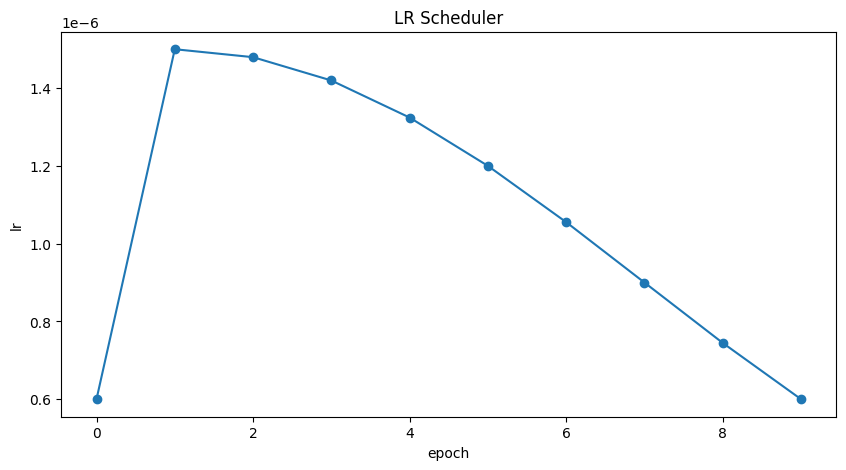

In [22]:
_=get_lr_callback(CFG.batch_size*CFG.replicas, plot=True)

# ☎️ | Callbacks

The function below will gather all the training callbacks, such as `lr_scheduler`, `model_checkpoint`, `wandb_logger`, and etc.

In [23]:
def get_callbacks(fold):
    callbacks = []
    lr_cb = get_lr_callback(CFG.batch_size*CFG.replicas)  # Get lr callback
    ckpt_cb = keras.callbacks.ModelCheckpoint(f'fold{fold}.keras',
                                              monitor='val_auc',
                                              save_best_only=True,
                                              save_weights_only=False,
                                              mode='max')  # Get Model checkpoint callback
    callbacks.extend([lr_cb, ckpt_cb])  # Add lr and checkpoint callbacks

    if CFG.wandb:  # If WandB is enabled
        wb_cbs = get_wb_callbacks(fold)  # Get WandB callbacks
        callbacks.extend(wb_cbs) 
        
    return callbacks  # Return the list of callbacks

# 🤖 | Modeling



## KerasNLP Classifier

<img src="https://keras.io/img/logo.png" width="400">

The `KerasNLP` library provides comprehensive, ready-to-use implementations of popular NLP model architectures. It features a variety of pre-trained models including `Bert`, `Roberta`, `DebertaV3`, and more. In this notebook, we'll showcase the usage of `DebertaV3`. However, feel free to explore all available models in the [KerasNLP documentation](https://keras.io/api/keras_nlp/models/). Also for a deeper understanding of `KerasNLP`, refer to the informative [getting started guide](https://keras.io/guides/keras_nlp/getting_started/).

Our approach involves using `keras_nlp.models.XXClassifier` to process each text and generatie logits. These logits are passed through a `softmax` function to produce the final output.

In [31]:
# def build_model():
#     # Create a DebertaV3Classifier model
#     classifier = keras_nlp.models.DebertaV3Classifier.from_preset(
#         CFG.preset,
#         preprocessor=None,
#         num_classes=1 # one output per one option, for five options total 5 outputs
#     )
#     inputs = classifier.input
#     logits = classifier(inputs)
        
#     # Compute final output
#     outputs = keras.layers.Activation("sigmoid")(logits)
#     model = keras.Model(inputs, outputs)
    
#     # Compile the model with optimizer, loss, and metrics
#     model.compile(
#         optimizer=keras.optimizers.AdamW(5e-6),
#         loss=keras.losses.BinaryCrossentropy(label_smoothing=0.02),
#         metrics=[
#             keras.metrics.AUC(name="auc"),
#         ],
#         jit_compile=True
#     )
#     return model

In [24]:
def build_model():

    # backbone
    backbone = keras_nlp.models.DebertaV3Backbone.from_preset(
        CFG.preset
    )

    # inputs
    token_ids = keras.Input(
        shape=(CFG.sequence_length,),
        dtype=tf.int32,
        name="token_ids"
    )

    padding_mask = keras.Input(
        shape=(CFG.sequence_length,),
        dtype=tf.int32,
        name="padding_mask"
    )

    # forward
    x = backbone({
        "token_ids": token_ids,
        "padding_mask": padding_mask,
    })

    # CLS token
    # x = x[:, 0, :]
    x = keras.layers.Lambda(lambda t: t[:, 0, :])(x)

    # dropout
    x = keras.layers.Dropout(0.2)(x)

    # classifier
    outputs = keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    # build model
    model = keras.Model(
        inputs={
            "token_ids": token_ids,
            "padding_mask": padding_mask,
        },
        outputs=outputs
    )

    # compile
    model.compile(
        # optimizer=keras.optimizers.AdamW(learning_rate=5e-6),
        optimizer=keras.optimizers.Adam(learning_rate=5e-6),
        loss=keras.losses.BinaryCrossentropy(
            label_smoothing=0.02
        ),
        metrics=[
            keras.metrics.AUC(name="auc"),
        ],
        jit_compile=False
    )

    return model

In [25]:
# with strategy.scope
model = build_model()

### Model Summary

In [26]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃ Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 200)       │       0 │ -                    │
│ (InputLayer)        │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ token_ids           │ (None, 200)       │       0 │ -                    │
│ (InputLayer)        │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ deberta_v3_backbone │ (None, 200, 768)  │ 183,83… │ padding_mask[0][0],  │
│ (DebertaV3Backbone) │                   │         │ token_ids[0][0]      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ lambda (Lambda)     │ (None, 768)       │       0 │ deberta_v3_backbone… │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dropout_12          │ (None, 768)       │       0 │ lambda[0][0]         │
│ (Dropout)           │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dense (Dense)       │ (None, 1)         │     769 │ dropout_12[0][0]     │
└─────────────────────┴───────────────────┴─────────┴──────────────────────┘

 Total params: 183,832,321 (701.26 MB)

 Trainable params: 183,832,321 (701.26 MB)

 Non-trainable params: 0 (0.00 B)

### Model Plot

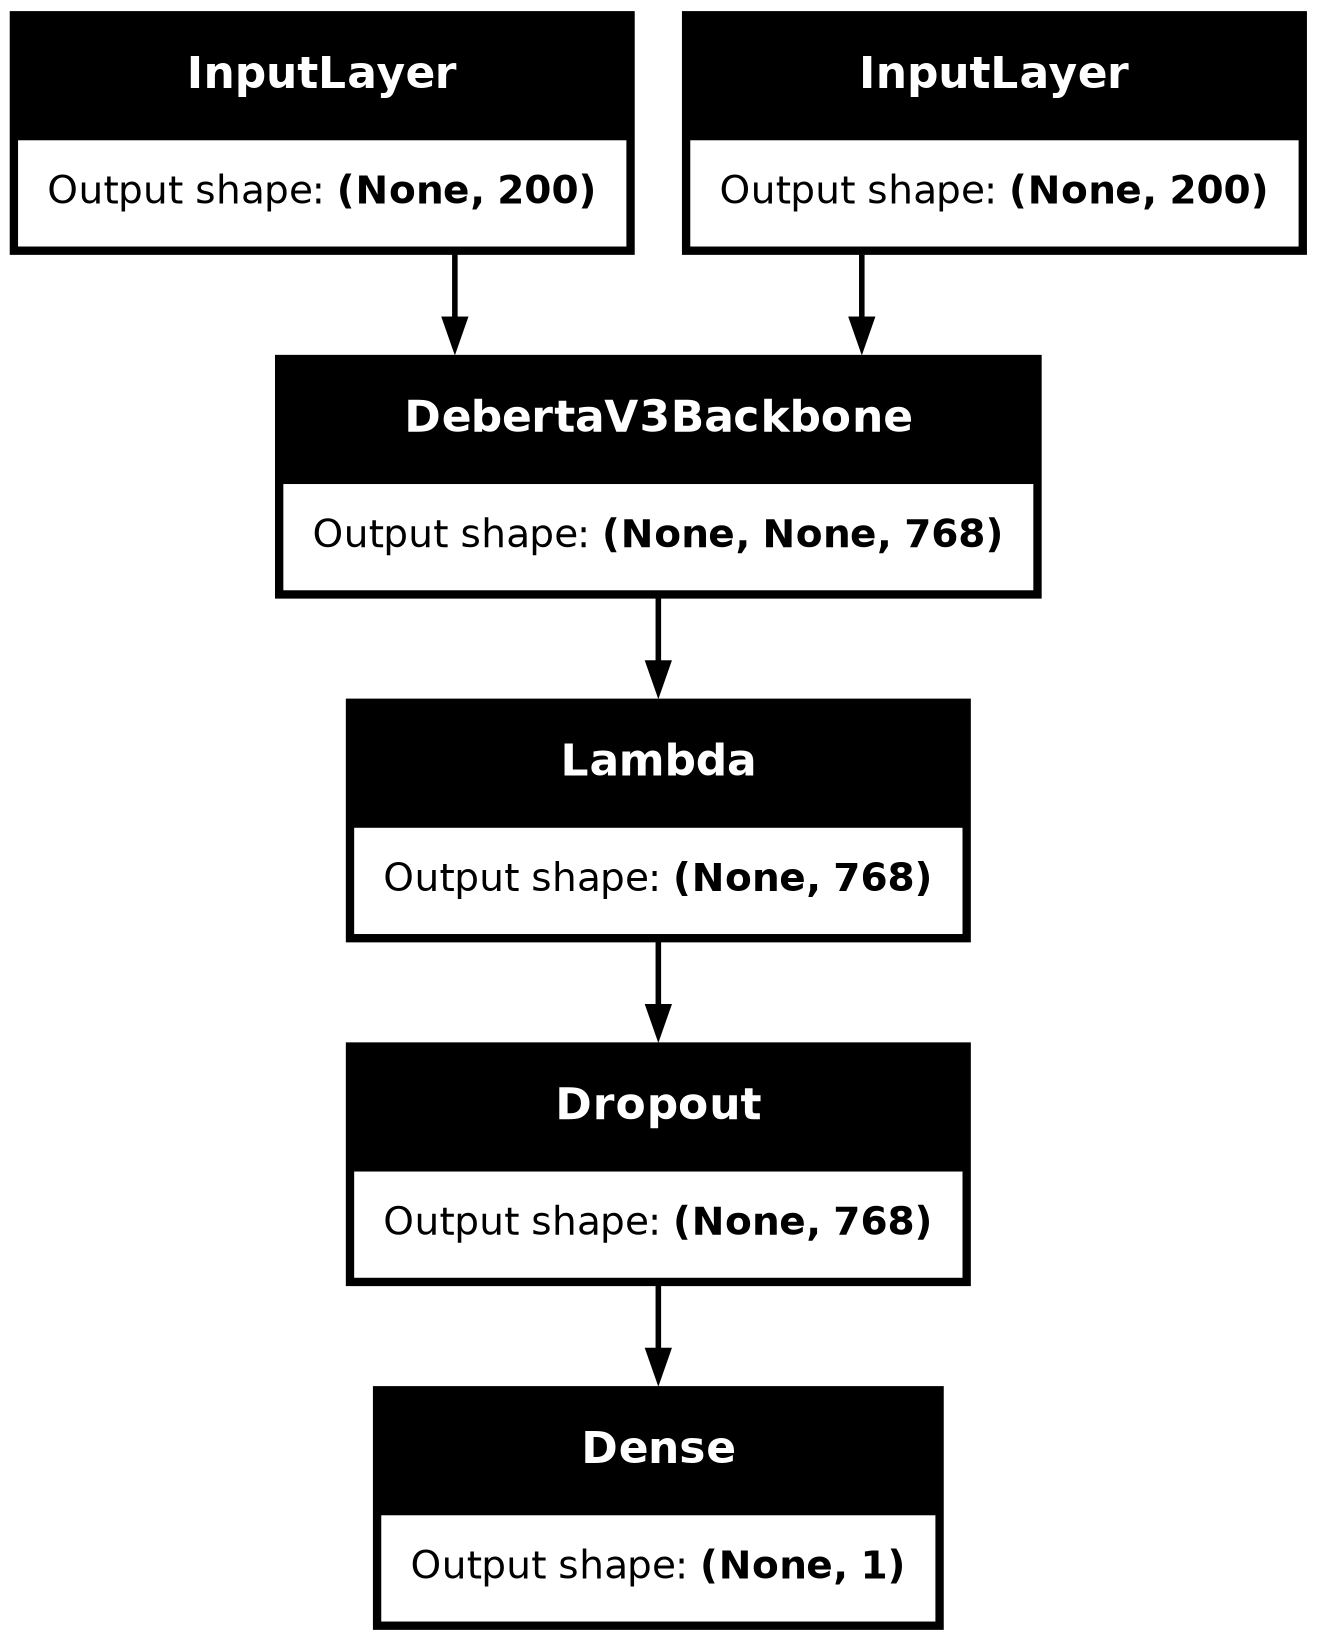

In [27]:
keras.utils.plot_model(model, show_shapes=True)

# 🚂 | Training

In [32]:
for fold in CFG.selected_folds:
    # Initialize Weights and Biases if enabled
    if CFG.wandb:
        run = wandb_init(fold)

    # Get train and validation datasets
    (train_ds, train_df), (valid_ds, valid_df) = get_datasets(fold)
    
    # Get callback functions for training
    callbacks = get_callbacks(fold)

    # Print training information
    print('#' * 50)
    print(f'\tFold: {fold + 1} | Model: {CFG.preset}\n\tBatch Size: {CFG.batch_size * CFG.replicas} | Scheduler: {CFG.scheduler}')
    print(f'\tNum Train: {len(train_df)} | Num Valid: {len(valid_df)}')
    print('#' * 50)
    
    # Clear TensorFlow session and build the model within the strategy scope
    K.clear_session()
    with strategy.scope():
        model = build_model()

    # Start training the model
    history = model.fit(
        train_ds,
        epochs=CFG.epochs,
        validation_data=valid_ds,
        callbacks=callbacks,
        steps_per_epoch=int(len(train_df) / CFG.batch_size / CFG.replicas),
    )
    
    # Find the epoch with the best validation accuracy
    best_epoch = np.argmax(model.history.history['val_auc'])
    best_auc = model.history.history['val_auc'][best_epoch]
    best_loss = model.history.history['val_loss'][best_epoch]

    # Print and display best results
    print(f'\n{"=" * 17} FOLD {fold} RESULTS {"=" * 17}')
    print(f'>>>> BEST Loss  : {best_loss:.3f}\n>>>> BEST AUC   : {best_auc:.3f}\n>>>> BEST Epoch : {best_epoch}')
    print('=' * 50)
    
    # Log best result on Weights and Biases (wandb) if enabled
    if CFG.wandb:
        log_wandb()  # Log results
        wandb.run.finish()  # Finish the run
    #   display(ipd.IFrame(run.url, width=1080, height=720)) # show wandb dashboard
    print("\n\n")

##################################################
	Fold: 1 | Model: deberta_v3_base_en
	Batch Size: 3 | Scheduler: cosine
	Num Train: 47121 | Num Valid: 11781
##################################################
Epoch 1/3
15707/15707 ━━━━━━━━━━━━━━━━━━━━ 42006s 3s/step - auc: 0.5174 - loss: 0.1441 - val_auc: 0.5330 - val_loss: 0.0590 - learning_rate: 6.0000e-07
Epoch 2/3
 3676/15707 ━━━━━━━━━━━━━━━━━━━━ 7:49:37 2s/step - auc: 0.5131 - loss: 0.1351

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



 4774/15707 ━━━━━━━━━━━━━━━━━━━━ 7:16:39 2s/step - auc: 0.4845 - loss: 0.1407

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



14839/15707 ━━━━━━━━━━━━━━━━━━━━ 35:43 2s/step - auc: 0.4953 - loss: 0.0887

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



15707/15707 ━━━━━━━━━━━━━━━━━━━━ 43091s 3s/step - auc: 0.4993 - loss: 0.0739 - val_auc: 0.4320 - val_loss: 0.0564 - learning_rate: 1.5000e-06
Epoch 3/3
 4445/15707 ━━━━━━━━━━━━━━━━━━━━ 8:58:03 3s/step - auc: 0.4943 - loss: 0.0216

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



10230/15707 ━━━━━━━━━━━━━━━━━━━━ 4:06:15 3s/step - auc: 0.4984 - loss: 0.0482

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Training Log
### [Click Here ➡️](https://wandb.ai/awsaf49/llm-fake-text) to check all the training logs in **WandB** dashboard.

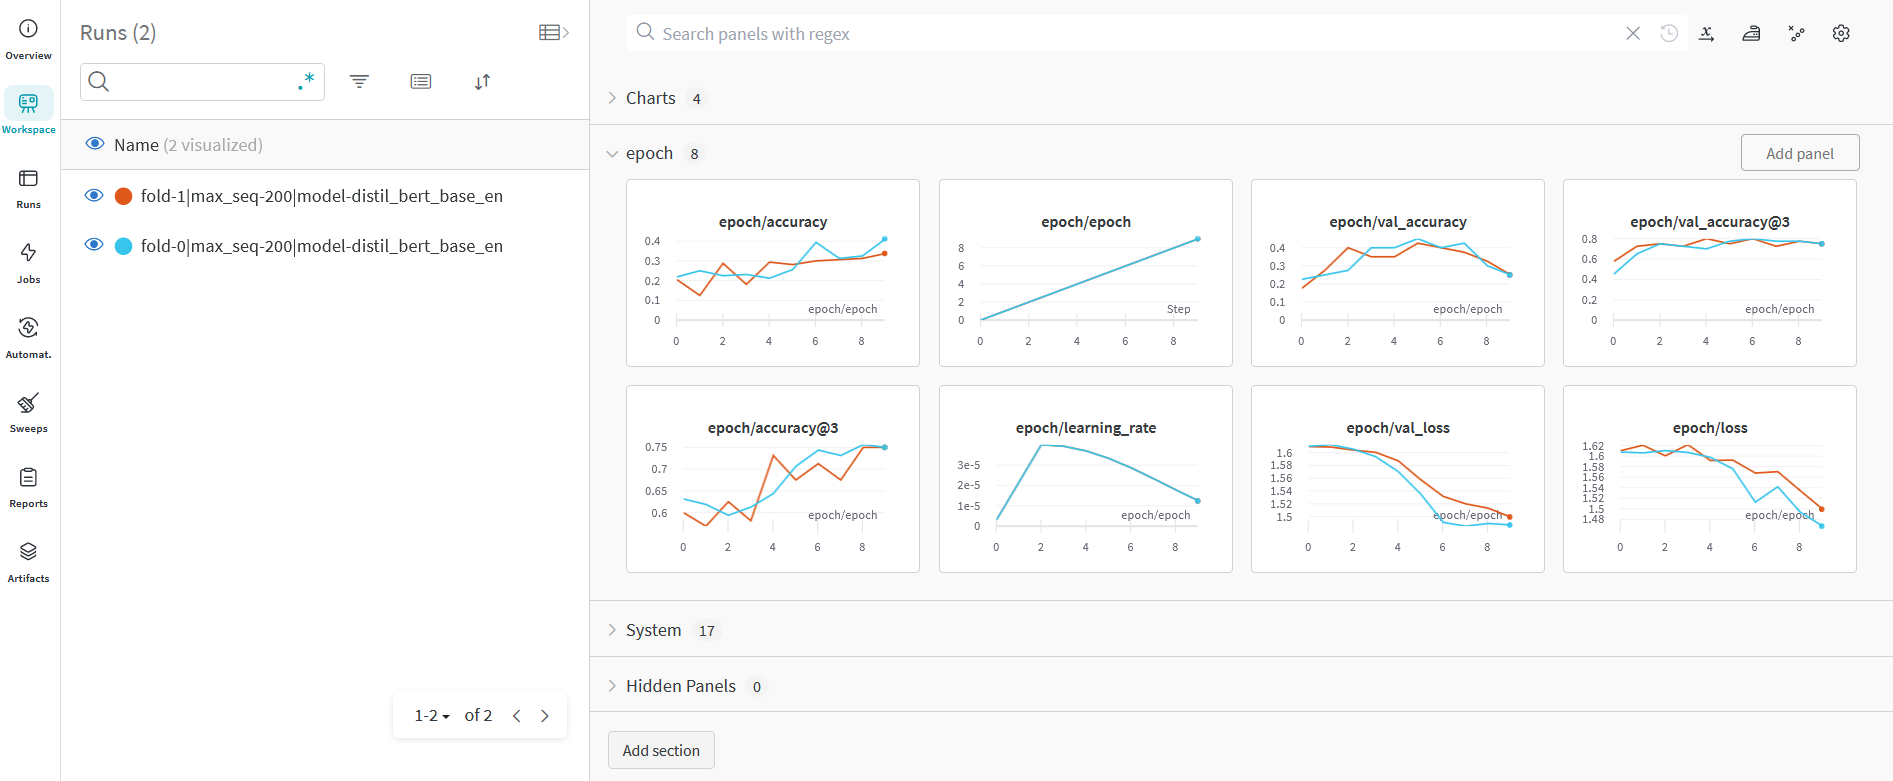

# 🧪 | Prediction

In [33]:
# Make predictions using the trained model on last validation data
predictions = model.predict(
    valid_ds,
    batch_size=min(CFG.batch_size * CFG.replicas * 2, len(valid_df)), # max batch size = valid size
    verbose=1
)

3927/3927 ━━━━━━━━━━━━━━━━━━━━ 2037s 518ms/step


In [34]:
# Format predictions and true answers
pred_answers = (predictions > 0.5).astype(int).squeeze()
true_answers = valid_df.label.values

# Check 5 Predictions
print("# Predictions\n")
for i in range(5):
    row = valid_df.iloc[i]
    text  = row.text
    pred_answer = CFG.label2name[pred_answers[i]]
    true_answer = CFG.label2name[true_answers[i]]
    print(f"❓ Text {i+1}:\n{text[:100]} .... {text[-100:]}\n")
    print(f"✅ True: {true_answer}\n")
    print(f"🤖 Predicted: {pred_answer}\n")
    print("-"*90, "\n")

# Predictions

❓ Text 1:
多知网3月26日消息，能否想象一下，如果一直坚持直营、坚持要自己做学校的新东方也开始做加盟，还要在小县城里开没有老师的教学中心，那将是种怎样的场景？对于这一点，刚开完新东方战略会议的俞敏洪没有开玩笑， .... 需求。无论是直营学校的稳步扩张，还是创新的加盟模式，都是新东方向更加广阔市场迈进的重要一步。在未来，我们可以期待看到一个更为开放、包容且富有活力的新东方，持续为中国广大的学习者提供优质教育资源和服务。

✅ True: LGT

🤖 Predicted: HLT

------------------------------------------------------------------------------------------ 

❓ Text 2:
字号:俄罗斯反潜机资料照片被驱赶的美军潜艇资料照片(图片来自美国海军网站)人民网8月9日电俄罗斯海军参谋部9日透露,该国北方舰队7日在巴伦支海“赶走了一艘入侵俄领海的美国核潜艇”。俄方称,当天俄军出动 .... 军称,“无法证实俄方的说法”,也无法对上述事件进行评论。不过,根据以往的说法分析,上述说法等于证实本次事件的存在。在乌克兰危机爆发后,美国和俄罗斯关系一直非常紧张。本次潜艇风波也是双方关系的真实写照。

✅ True: LGT

🤖 Predicted: HLT

------------------------------------------------------------------------------------------ 

❓ Text 3:
德国人文主义哲学家恩斯特·卡西尔的《人论》、《符号形式的哲学》、《符号·神话·文化》等译成中文以后，受到国内学术界的关注。他的西方人文主义及广泛发展引起人类学思潮，随着他的符号主义人类学进入国内的视野 .... 成的对于社会的感性认识，并且是在认识的基础上的形象化。这样一种关系使得神话和符号有着复杂的关系，神话和符号都是模糊的感性的认识，并且都有着独特的含义。神话的内容和其中蕴涵的意味都是模糊的，不甚清楚的。

✅ True: HWT

🤖 Predicted: HLT

----------------------------------------------------

# ✍️ | Reference
* [LLM Science Exam: KerasCore + KerasNLP [TPU]](https://www.kaggle.com/code/awsaf49/llm-science-exam-kerascore-kerasnlp-tpu)
* [Keras NLP](https://keras.io/api/keras_nlp/)
* [Triple Stratified KFold with TFRecords](https://www.kaggle.com/code/cdeotte/triple-stratified-kfold-with-tfrecords) by @cdeotte

In [30]:
# !rm -r /kaggle/working/wandb  

完整保存代码（直接复制）

放在训练结束后：

In [35]:
import os
import shutil

# ====================================================
# Save Model
# ====================================================

SAVE_DIR = "./kaggle/input/daigt-kerasnlp-ckpt-nlpcc"

os.makedirs(SAVE_DIR, exist_ok=True)

model.save(f"{SAVE_DIR}/deberta_fake_text.keras")

model.save_weights(
    f"{SAVE_DIR}/deberta_fake_text.weights.h5"
)

print("Model saved!")

Model saved!


In [36]:
# ====================================================
# Save Tokenizer Vocab
# ====================================================

VOCAB_SAVE_DIR = "./kaggle/input/keras-nlp-deberta-v3-base-en-vocab-ds-nlpcc"
vocab_path = "models--microsoft--deberta-v3-base/spm.model"
os.makedirs(VOCAB_SAVE_DIR, exist_ok=True)

shutil.copy(
    vocab_path,
    f"{VOCAB_SAVE_DIR}/vocab.spm"
)

print("Tokenizer vocab saved!")

Tokenizer vocab saved!


In [37]:
import keras

In [38]:
model.save("model-nlpcc.keras")